Nama : Farsya Runa Supriyatna
Dataset : 

HR Analytics: Employee Retention and Turnover

LATAR BELAKANG

Sumber daya manusia merupakan aset penting yang menentukan keberhasilan suatu perusahaan, namun permasalahan yang sering muncul adalah tingginya tingkat keluar-masuk karyawan (employee turnover). Tingginya turnover dapat menimbulkan dampak negatif berupa meningkatnya biaya rekrutmen dan pelatihan, serta menurunnya produktivitas perusahaan. Beberapa faktor yang diduga berpengaruh terhadap keputusan karyawan untuk keluar antara lain tingkat kepuasan kerja yang rendah, beban kerja yang berlebihan, minimnya kesempatan promosi, serta kompensasi atau gaji yang tidak sesuai. Oleh karena itu, diperlukan analisis terhadap data karyawan untuk mengidentifikasi faktor-faktor utama yang mendorong turnover sehingga perusahaan dapat merumuskan strategi yang tepat dalam meningkatkan retensi karyawan.

PROBLEM STATEMENT

1. Perusahaan tidak lagi memerlukan Work_accident karena kurang relevan dengan data ini.
2. Mengapa tingkat turnover karyawan dalam perusahaan masih tinggi?
3. Faktor apa saja yang paling memengaruhi keputusan karyawan untuk keluar?

In [1]:
#SETUP
import numpy as nu
import pandas as pd
import scipy as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

KeyboardInterrupt: 

In [28]:
#membuat data frame
df = pd.read_csv('HR_comma_sep.csv')

In [29]:
import pandas as pd
df = pd.read_csv('HR_comma_sep.csv')

df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [30]:
df.shape

(14999, 10)

In [31]:
#salinan data dengan nama clean
clean = df.copy()

In [32]:
#data dicek kesesuaian tipe data
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [33]:
clean.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [34]:
df = df.drop(columns=['Work_accident'])

In [35]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,1,0,sales,low
1,0.80,0.86,5,262,6,1,0,sales,medium
2,0.11,0.88,7,272,4,1,0,sales,medium
3,0.72,0.87,5,223,5,1,0,sales,low
4,0.37,0.52,2,159,3,1,0,sales,low


Analisis dan Perhitungan (Metode Visual dan Statistik)

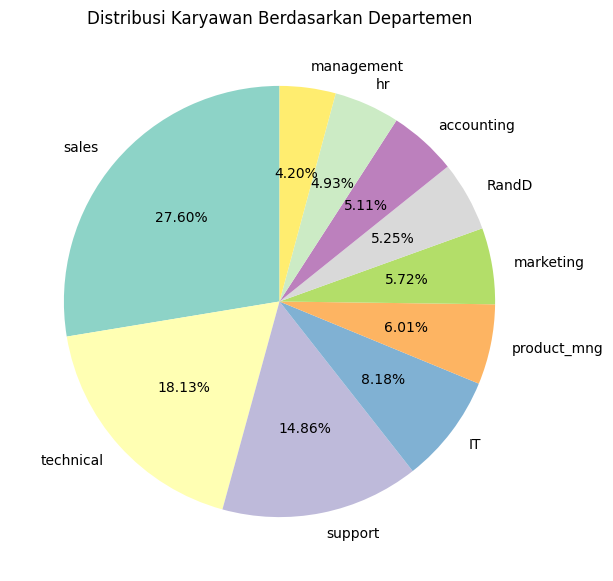

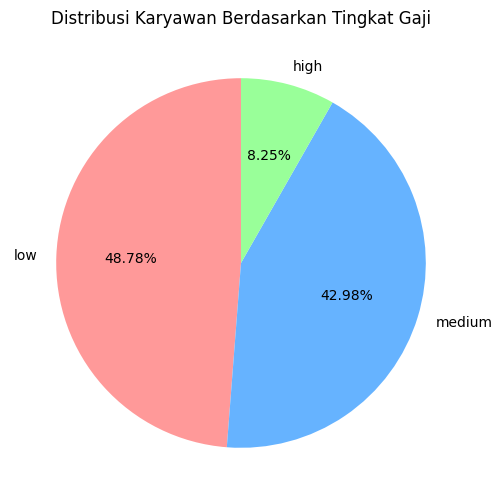

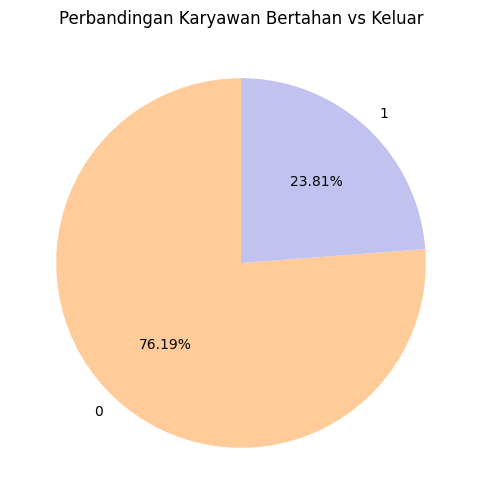

In [37]:
plt.figure(figsize=(7,7))
df['sales'].value_counts().plot.pie(autopct='%1.2f%%', startangle=90, cmap='Set3')
plt.title("Distribusi Karyawan Berdasarkan Departemen")
plt.ylabel("")  # biar tulisan 'sales' hilang di samping
plt.show()

plt.figure(figsize=(6,6))
df['salary'].value_counts().plot.pie(autopct='%1.2f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Distribusi Karyawan Berdasarkan Tingkat Gaji")
plt.ylabel("")
plt.show()

plt.figure(figsize=(6,6))
df['left'].value_counts().plot.pie(autopct='%1.2f%%', startangle=90, colors=['#ffcc99','#c2c2f0'])
plt.title("Perbandingan Karyawan Bertahan vs Keluar")
plt.ylabel("")
plt.show()


Tingkat kepuasan Karyawan

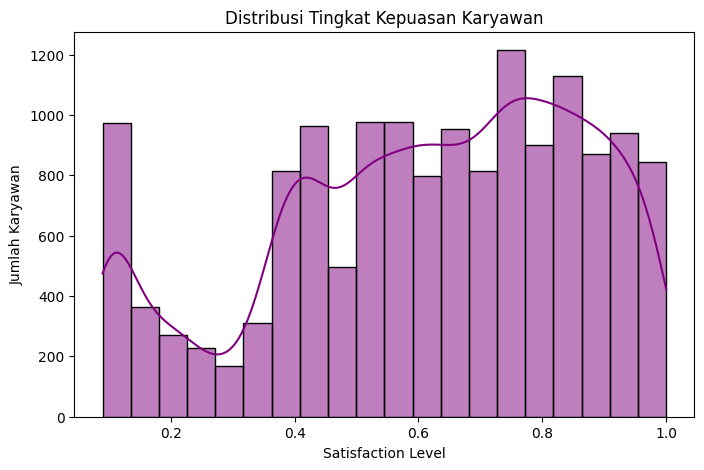

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df['satisfaction_level'], bins=20, kde=True, color="purple")
plt.title("Distribusi Tingkat Kepuasan Karyawan")
plt.xlabel("Satisfaction Level")
plt.ylabel("Jumlah Karyawan")
plt.show()

Kesimpulan

Tingkat turnover karyawan dalam perusahaan masih tinggi karena adanya beberapa faktor yang memengaruhi keputusan karyawan untuk keluar. Faktor-faktor utama yang terlihat dari analisis data adalah tingkat kepuasan kerja yang rendah, beban kerja yang berlebihan, kompensasi yang kurang kompetitif, serta keterbatasan peluang promosi dan pengembangan karier. Kondisi ini membuat karyawan merasa kurang dihargai dan tidak memiliki prospek jangka panjang di perusahaan sehingga memilih untuk meninggalkan pekerjaannya.

Saran

Meningkatkan kepuasan kerja melalui lingkungan kerja yang lebih nyaman, penghargaan atas kinerja, dan budaya kerja yang positif.

Menyeimbangkan beban kerja agar karyawan tidak mengalami stres atau kelelahan berlebih.

Meninjau kembali sistem kompensasi agar lebih sesuai dengan standar industri dan beban kerja.

Menyediakan jalur karier dan promosi yang jelas sehingga karyawan memiliki motivasi untuk bertahan lebih lama.

Mengadakan program pelatihan dan pengembangan untuk meningkatkan keterampilan sekaligus memberi rasa kepemilikan terhadap perusahaan.